In [1]:
import os
# Disable tokenizers parallelism
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install git+https://github.com/csebuetnlp/normalizer
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.8 MB/s eta 0:00:00
  Cloning https://github.com/csebuetnlp/normalizer to /tmp/pip-req-build-g4l1uzem
  Running command git clone --filter=blob:none --quiet https://github.com/csebuetnlp/normalizer /tmp/pip-req-build-g4l1uzem
  Resolved https://github.com/csebuetnlp/normalizer to commit d405944dde5ceeacb7c2fd3245ae2a9dea5f35c9
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
  Created wheel for normalizer: filename=normalizer-0.0.1-py3-none-any.whl size=6859 sha256=c5d86df4fc85f97d88a65f4e4496faacd8afb1c294d27dac755b7a1971552a70
  Stored in directory: /tmp/pip-ephem-wheel-cache-manvti65/wheels/2e/79/9c/cd96d490298305d51d2da11484bb2c25fd1f759a6906708282
  Created wheel for emoji: filename=em

In [3]:
#!pip uninstall tensorflow transformers datasets evaluate
!pip install tensorflow transformers datasets evaluate imblearn

In [4]:
import pandas as pd
from collections import Counter
import re
#from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
import evaluate
#from datasets import load_metric
#import datasets
#pd.set_option('display.max_rows', 500)
#pd.set_option('display.max_columns', 500)
#pd.set_option('display.width', 1000)
#from datasets import Dataset, DatasetDict
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import random
np.object = object
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from transformers import AutoTokenizer, DataCollatorWithPadding,BertModel,AutoTokenizer,AutoConfig,RobertaModel
from transformers import RobertaTokenizer, RobertaModel
from collections import defaultdict
import torch
import warnings
warnings.filterwarnings('ignore')
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from transformers import AdamW
from sklearn.model_selection import KFold
from torch.cuda import amp

import gc
gc.enable()

In [5]:
def set_random_seed(random_seed):
    random.seed(random_seed)
    np.random.seed(random_seed)
    os.environ["PYTHONHASHSEED"] = str(random_seed)

    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)

    torch.backends.cudnn.deterministic = True

In [6]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
model_name = "XLM-RoBERTa+CNN"
title = "for Token Classification Using " + model_name
title_figure = "/kaggle/working/ITN_" + model_name
model_path = "/kaggle/working/" + model_name
# Load data from CSV
df_input = pd.read_csv('/kaggle/input/ec-and-tn-datasets/_115000_TN_Oversampled_Final_Data.csv', encoding='utf-16')
df_input['CLASS'].value_counts()

CLASS
BNG_TEXT         115000
ENG_TEXT         115000
ORDINAL          115000
FLOAT            115000
FRACTIONAL       115000
DATE             115000
TELEPHONE        115000
GAME             115000
PERCENTAGE       115000
EQUATION         115000
HOMO_TEXT        115000
RANGE            115000
NON_HOMO_TEXT    115000
CARDINAL         115000
ROMAN_NUM        115000
MONEY            115000
ENG_NUM          115000
YEAR             115000
TIME             115000
ARABIC_TEXT      115000
OTHERS_TEXT      115000
PUNCTUATION      115000
UNKNOWN_TEXT     115000
SPECIAL SIGN     115000
ABBREVIATION     115000
EMOZI            115000
Name: count, dtype: int64

In [7]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Reshape the 'BEFORE SENTENCE' column into a 2D array
X = df_input["AFTER"].values.reshape(-1, 1)  # Reshape to a 2D array
y = df_input["LABEL"]

# Define the desired sampling strategy
undersampling_strategy = {i: 30000 for i in range(26)}

# Create an instance of RandomUnderSampler with the specified sampling strategy
under_sampler = RandomUnderSampler(random_state=2017, sampling_strategy=undersampling_strategy)

# Resample the dataset
X_resampled, y_resampled = under_sampler.fit_resample(X, y )

# Convert X_resampled back to a 1D array if necessary
X_resampled = X_resampled.flatten()

# Create a DataFrame using the resampled data
df = pd.DataFrame({
    'AFTER': X_resampled,  # Feature column
    'LABEL': y_resampled    # Target column
})

# Check the first few rows of the new DataFrame and value counts of labels
df["LABEL"].value_counts()


LABEL
0     30000
1     30000
2     30000
3     30000
4     30000
5     30000
6     30000
7     30000
8     30000
9     30000
10    30000
11    30000
12    30000
13    30000
14    30000
15    30000
16    30000
17    30000
18    30000
19    30000
20    30000
21    30000
22    30000
23    30000
24    30000
25    30000
Name: count, dtype: int64

In [8]:
with pd.option_context('display.max_colwidth',0):
    display(df.sample(n=10))

,AFTER,LABEL
281601,এক লক্ষ দশ হাজার তিন ভাগ ঊনচল্লিশ লক্ষ এক শত ষোল সমান ছয় কোটি পঞ্চাশ লক্ষ ছাব্বিশ,9
355237,এক হাজার ছয় শত ঊনচল্লিশ থেকে এক হাজার ছয় শত ঊনষাট,11
179442,তেসরা ডিসেম্বর দুই হাজার তিরাশি,5
283814,এক লক্ষ দশ হাজার যোগ ঊনচল্লিশ লক্ষ এক শত পঁয়তাল্লিশ সমান ছয় কোটি পঞ্চাশ লক্ষ বত্রিশ,9
640167,"'"":",21
527661,বাইশশো সাতান্ন,17
624231,裸,20
770781,:-),25
737540,সেন্টিমিটার,24
174392,ঊনিশে নভেম্বর উনিশশো ছেষট্টি,5


In [9]:
df.shape

(780000, 2)

In [10]:
df.shape[0]*0.7

546000.0

In [11]:
df["LABEL"].value_counts()

LABEL
0     30000
1     30000
2     30000
3     30000
4     30000
5     30000
6     30000
7     30000
8     30000
9     30000
10    30000
11    30000
12    30000
13    30000
14    30000
15    30000
16    30000
17    30000
18    30000
19    30000
20    30000
21    30000
22    30000
23    30000
24    30000
25    30000
Name: count, dtype: int64

# Data Visualization 

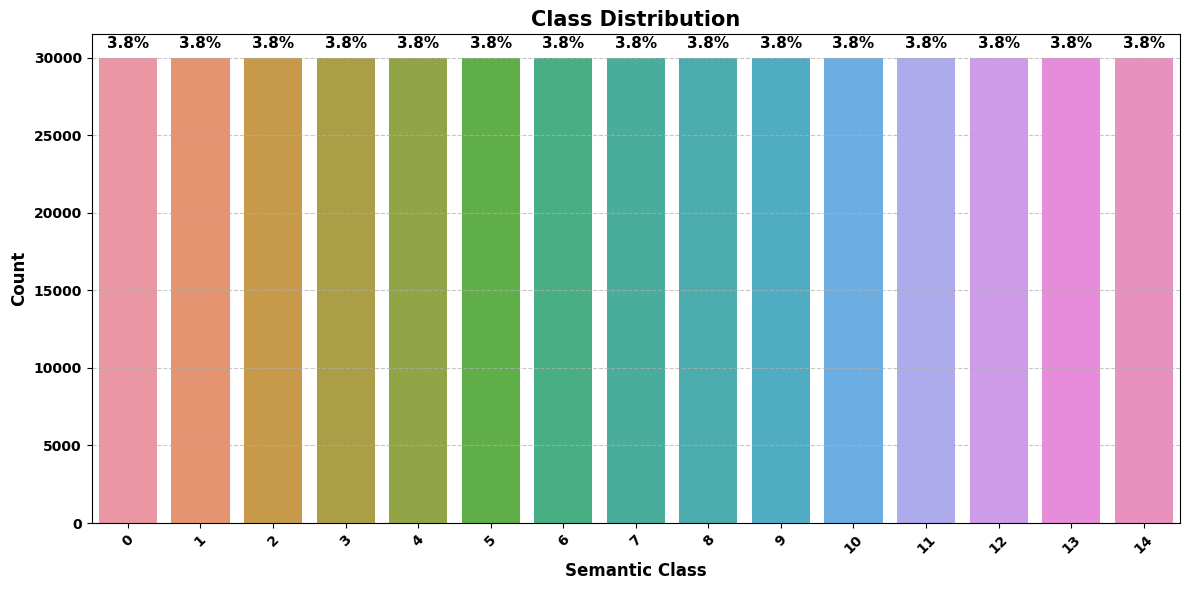

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x, fig_y, col, top_x, rotation, xlabel, title, df):
    """
    Create a count plot with percentage annotations.

    Parameters:
    - fig_x (int): Width of the figure.
    - fig_y (int): Height of the figure.
    - col (str): Column name for counting.
    - top_x (int): Number of top categories to display.
    - rotation (int): Rotation angle for x-axis labels.
    - xlabel (str): Label for the x-axis.
    - title (str): Title of the plot.
    - df (DataFrame): DataFrame containing the data.
    """
    plt.figure(figsize=(fig_x, fig_y))

    # Set the color palette for the plot
    sns.set_palette("viridis")

    # Calculate total count for percentage calculation
    total = float(len(df))

    # Create count plot with a color palette
    ax = sns.countplot(x=col, data=df, order=df[col].value_counts().iloc[:top_x].index)

    # Annotate each bar with the percentage
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', weight='bold', size=11, color='black')

    # Customize plot appearance
    plt.xticks(rotation=rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(xlabel, weight='bold', size=12)
    plt.ylabel('Count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)

    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example usage
countplot(12, 6, 'LABEL', 15, 45, 'Semantic Class', 'Class Distribution', df)


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test1, y_train, y_test1 = train_test_split(df['AFTER'], df['LABEL'], test_size=0.3, random_state=42, stratify=df['LABEL'])
X_val, X_test, y_val, y_test = train_test_split(X_test1,y_test1, test_size=0.5, random_state=42, stratify=y_test1)

In [14]:
X_train.shape

(546000,)

In [15]:
train_df = pd.DataFrame()
train_df['AFTER'] = X_train.values
train_df['LABEL'] = y_train.values

In [16]:
val_df = pd.DataFrame()
val_df['AFTER'] = X_val.values
val_df['LABEL'] = y_val.values

In [17]:
test_df = pd.DataFrame()
test_df['AFTER'] = X_test.values
test_df['LABEL'] = y_test.values

In [18]:
train_df.shape

(546000, 2)

In [19]:
train_df.head()

,AFTER,LABEL
0,¿,22
1,এক দশমিক আট ডলার,15
2,কোনো আইনসভা,10
3,বারো ছত্রিশ বিপক্ষ,7
4,ও কাল যিহোবার,12


In [20]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117000 entries, 0 to 116999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   AFTER   117000 non-null  object
 1   LABEL   117000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


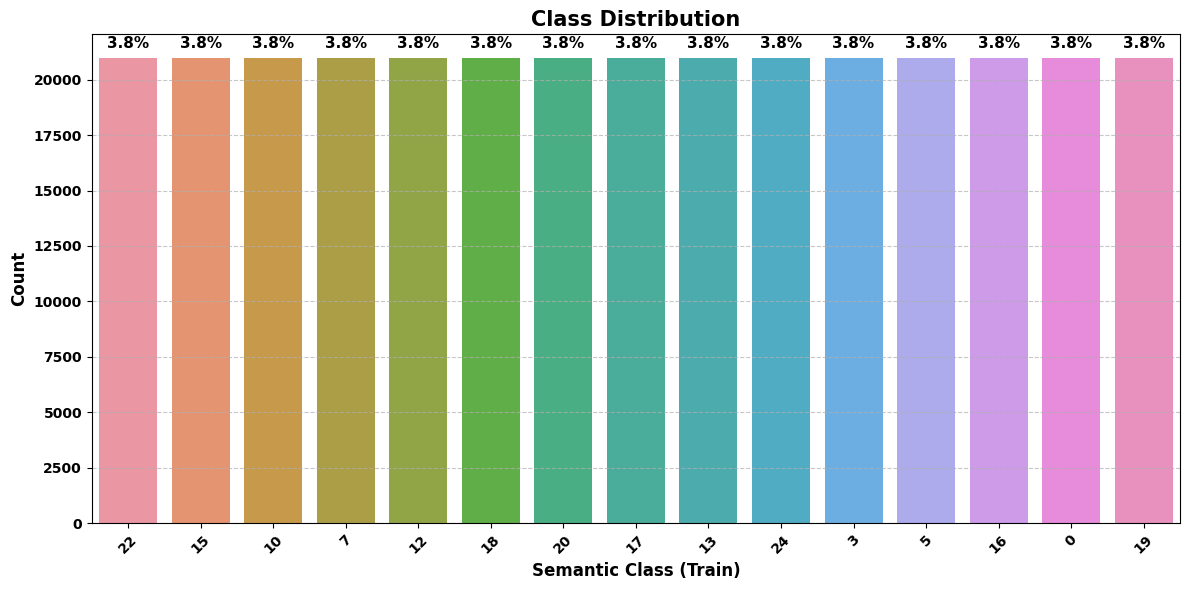

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x, fig_y, col, top_x, rotation, xlabel, title, df):
    """
    Create a count plot with percentage annotations.

    Parameters:
    - fig_x (int): Width of the figure.
    - fig_y (int): Height of the figure.
    - col (str): Column name for counting.
    - top_x (int): Number of top categories to display.
    - rotation (int): Rotation angle for x-axis labels.
    - xlabel (str): Label for the x-axis.
    - title (str): Title of the plot.
    - df (DataFrame): DataFrame containing the data.
    """
    plt.figure(figsize=(fig_x, fig_y))

    # Set the color palette for the plot
    sns.set_palette("viridis")

    # Calculate total count for percentage calculation
    total = float(len(train_df))

    # Create count plot with a color palette
    ax = sns.countplot(x=col, data=train_df, order=train_df[col].value_counts().iloc[:top_x].index)

    # Annotate each bar with the percentage
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', weight='bold', size=11, color='black')

    # Customize plot appearance
    plt.xticks(rotation=rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(xlabel, weight='bold', size=12)
    plt.ylabel('Count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)

    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example usage
countplot(12, 6, 'LABEL', 15, 45, 'Semantic Class (Train)', 'Class Distribution', df)


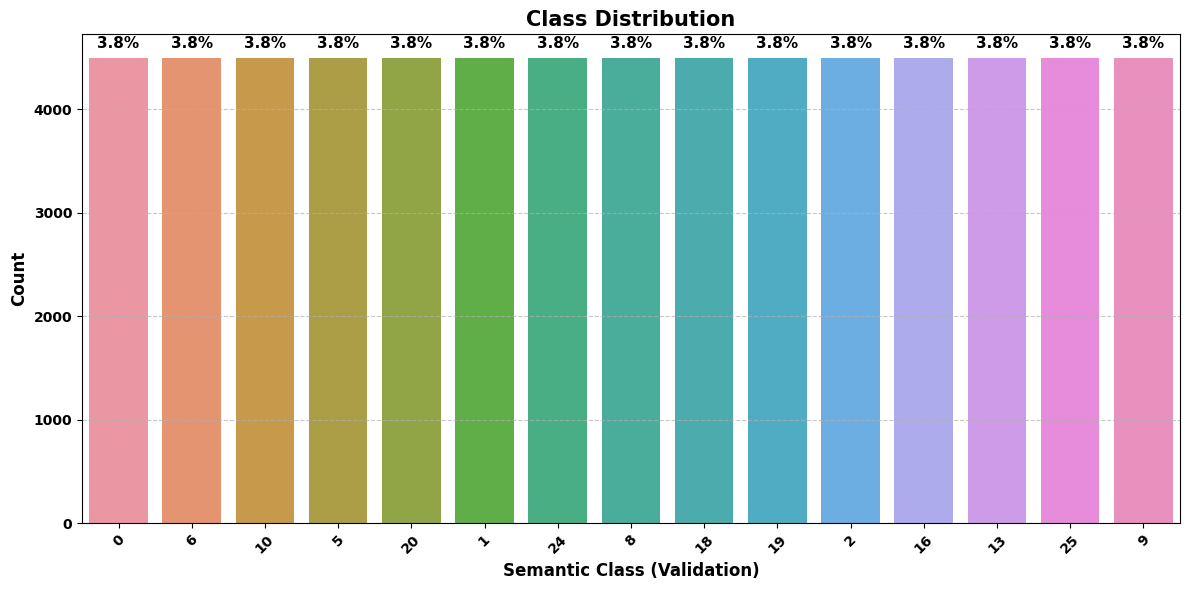

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x, fig_y, col, top_x, rotation, xlabel, title, df):
    """
    Create a count plot with percentage annotations.

    Parameters:
    - fig_x (int): Width of the figure.
    - fig_y (int): Height of the figure.
    - col (str): Column name for counting.
    - top_x (int): Number of top categories to display.
    - rotation (int): Rotation angle for x-axis labels.
    - xlabel (str): Label for the x-axis.
    - title (str): Title of the plot.
    - df (DataFrame): DataFrame containing the data.
    """
    plt.figure(figsize=(fig_x, fig_y))

    # Set the color palette for the plot
    sns.set_palette("viridis")

    # Calculate total count for percentage calculation
    total = float(len(val_df))

    # Create count plot with a color palette
    ax = sns.countplot(x=col, data=val_df, order=val_df[col].value_counts().iloc[:top_x].index)

    # Annotate each bar with the percentage
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', weight='bold', size=11, color='black')

    # Customize plot appearance
    plt.xticks(rotation=rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(xlabel, weight='bold', size=12)
    plt.ylabel('Count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)

    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example usage
countplot(12, 6, 'LABEL', 15, 45, 'Semantic Class (Validation)', 'Class Distribution', df)


In [23]:
from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [24]:
class Config:
    num_classes = 26
    path =  "FacebookAI/xlm-roberta-base"
    num_epochs = 10
    batch_size = 32
    SEED = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

config = Config()

In [25]:
# Step 1: Load the XLM-RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.path)

# Step 2: Extract vocabulary tokens (assuming you want to use a custom list)
# Here, you'll need to preprocess `df_input["AFTER"]` to extract any unique words you want to add

# Create a list of new tokens (for example, you could tokenize the text and gather new tokens)
new_tokens = set()
for text in df_input["AFTER"]:
    tokens = tokenizer.tokenize(text)  # Tokenize the text
    new_tokens.update(tokens)  # Add unique tokens

# Step 3: Add new tokens to the tokenizer
# Add the tokens to the tokenizer (but ensure they are not already in the tokenizer's vocabulary)
tokenizer.add_tokens(list(new_tokens))

# Continue with the tokenization and training process as before

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

26116

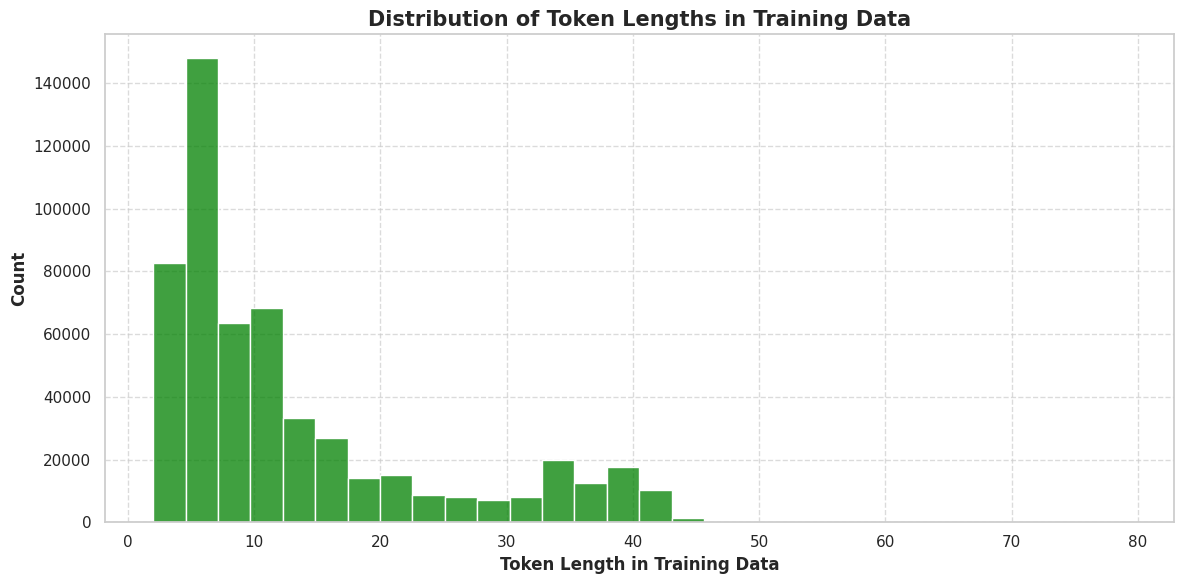

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token counts
token_counts = []
for _, row in train_df.iterrows():
    token_count = len(tokenizer.encode(
        row["AFTER"],
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

# Set up the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Improve background style for readability

# Plot histogram
sns.histplot(token_counts, bins=30, kde=False, color='green')

# Customize plot appearance
plt.xlabel("Token Length in Training Data", weight='bold', size=12)
plt.ylabel('Count', weight='bold', size=12)
plt.title("Distribution of Token Lengths in Training Data", weight='bold', size=15)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Display the plot
plt.tight_layout()
plt.show()

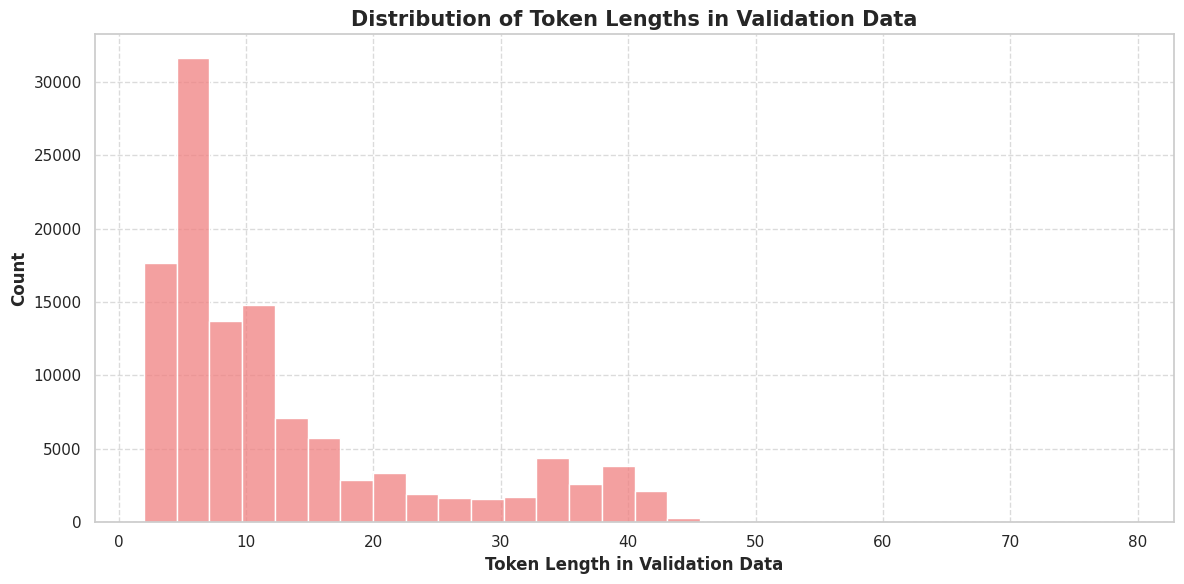

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token counts for validation data
token_counts = []
for _, row in val_df.iterrows():
    token_count = len(tokenizer.encode(
        row["AFTER"],
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

# Set up the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Improve background style for readability

# Plot histogram
sns.histplot(token_counts, bins=30, kde=False, color='lightcoral')

# Customize plot appearance
plt.xlabel("Token Length in Validation Data", weight='bold', size=12)
plt.ylabel('Count', weight='bold', size=12)
plt.title("Distribution of Token Lengths in Validation Data", weight='bold', size=15)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Display the plot
plt.tight_layout()
plt.show()


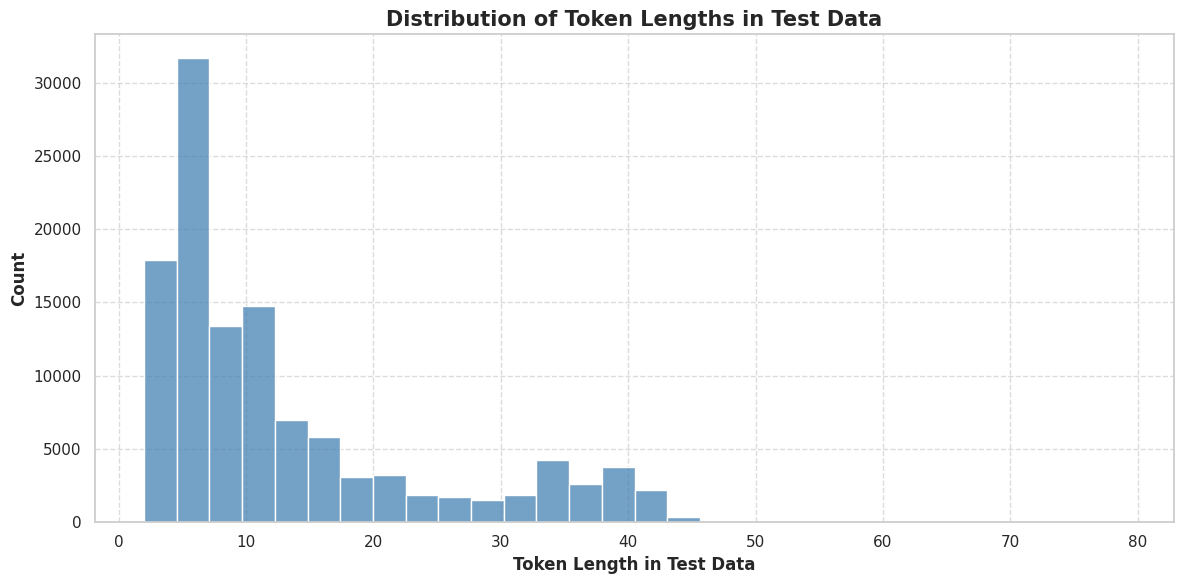

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token counts for test data
token_counts = []
for _, row in test_df.iterrows():
    token_count = len(tokenizer.encode(
        row["AFTER"],
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

# Set up the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Improve background style for readability

# Plot histogram
sns.histplot(token_counts, bins=30, kde=False, color='steelblue')

# Customize plot appearance
plt.xlabel("Token Length in Test Data", weight='bold', size=12)
plt.ylabel('Count', weight='bold', size=12)
plt.title("Distribution of Token Lengths in Test Data", weight='bold', size=15)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Display the plot
plt.tight_layout()
plt.show()


In [29]:
max_token_length = 40
def tokenize_function(example):
    return tokenizer(example["AFTER"], padding = True, truncation=True, max_length=max_token_length)

# mapping dataset (actually texts) into tokenized values of pretrained model (provided in path)
tokenized_train_datasets = train_dataset.map(tokenize_function, batched=True)
tokenized_val_datasets = val_dataset.map(tokenize_function, batched=True)
tokenized_test_datasets = test_dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/546000 [00:00<?, ? examples/s]

Map:   0%|          | 0/117000 [00:00<?, ? examples/s]

Map:   0%|          | 0/117000 [00:00<?, ? examples/s]

In [30]:
tokenized_train_datasets

Dataset({
    features: ['AFTER', 'LABEL', 'input_ids', 'attention_mask'],
    num_rows: 546000
})

In [31]:
tokenized_val_datasets

Dataset({
    features: ['AFTER', 'LABEL', 'input_ids', 'attention_mask'],
    num_rows: 117000
})

In [32]:
tokenized_test_datasets

Dataset({
    features: ['AFTER', 'LABEL', 'input_ids', 'attention_mask'],
    num_rows: 117000
})

In [33]:
tokenized_train_datasets = tokenized_train_datasets.remove_columns(['AFTER'])
tokenized_val_datasets = tokenized_val_datasets.remove_columns(['AFTER'])
tokenized_test_datasets = tokenized_test_datasets.remove_columns(['AFTER'])
tokenized_train_datasets.set_format("torch")
tokenized_val_datasets.set_format("torch")
tokenized_test_datasets.set_format("torch")

In [34]:
tokenized_test_datasets.column_names

['LABEL', 'input_ids', 'attention_mask']

In [35]:
import torch
import torch.nn as nn
from transformers import BertModel, AutoModel

class ClassifierModel(nn.Module):
    def __init__(self):
        super(ClassifierModel, self).__init__()
        self.bert = AutoModel.from_pretrained(config.path)
        self.drop = nn.Dropout(p=0.45)
        self.conv = nn.Conv1d(in_channels=768, out_channels=256, kernel_size=3, padding=1)  # DPCNN Layer
        self.fc = nn.Linear(256, config.num_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = output[0].transpose(1, 2)  # Transpose for convolution
        x = self.conv(x)  # DPCNN Conv Layer
        x = x.max(dim=2)[0]  # Max-pooling across time steps
        x = self.drop(x)
        return self.fc(x)


# New Code

In [36]:
import numpy as np
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    cohen_kappa_score,
    matthews_corrcoef
)
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import torch.cuda.amp as amp
import time
from transformers import get_scheduler
from torch.utils.data import DataLoader

class Engine:
    def __init__(self, model, optimizer, scheduler=None):
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler

    @staticmethod
    def loss_fn(target, pred):
        loss_fct = nn.CrossEntropyLoss()
        return loss_fct(pred, target)

    @staticmethod
    def compute_metrics(labels, preds):
        y_true = labels.cpu().numpy()
        y_pred = torch.argmax(preds, axis=-1).cpu().numpy()

        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        kappa = cohen_kappa_score(y_true, y_pred)
        mcc = matthews_corrcoef(y_true, y_pred)

        return accuracy, precision, recall, f1, mse, mae, kappa, mcc

    def train(self, train_dataloader, scaler, num_training_steps):
        self.model.train()
        total_training_loss = 0.0
        all_labels = []
        all_preds = []
        DEVICE = config.device
        progress_bar = tqdm(range(num_training_steps))

        for data in train_dataloader:
            input_ids = data["input_ids"].to(DEVICE)
            attention_mask = data["attention_mask"].to(DEVICE)
            target = data["LABEL"].to(DEVICE)
            self.optimizer.zero_grad()

            with amp.autocast():
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target, pred)

            total_training_loss += loss.item()
            scaler.scale(loss).backward()
            scaler.step(self.optimizer)
            scaler.update()

            if self.scheduler:
                self.scheduler.step()
            progress_bar.update(1)

            # Collect predictions and true labels for metrics
            all_labels.extend(target.cpu().numpy())
            all_preds.extend(pred.detach().cpu().numpy())  # Detach before converting to numpy

        # Compute metrics at the end of the epoch
        metrics = self.compute_metrics(torch.tensor(all_labels), torch.tensor(all_preds))
        accuracy, precision, recall, f1, mse, mae, kappa, mcc = metrics

        return total_training_loss / len(train_dataloader), accuracy, precision, recall, f1, mse, mae, kappa, mcc

    def evaluate(self, eval_dataloader):
        self.model.eval()
        val_loss = 0
        all_labels = []
        all_preds = []
        DEVICE = config.device

        with torch.no_grad():
            for data in tqdm(eval_dataloader):
                input_ids = data["input_ids"].to(DEVICE)
                attention_mask = data["attention_mask"].to(DEVICE)
                target = data["LABEL"].to(DEVICE)

                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target, pred)
                val_loss += loss.item()

                all_labels.extend(target.cpu().numpy())
                all_preds.extend(pred.cpu().numpy())

        # Compute validation metrics
        metrics = self.compute_metrics(torch.tensor(all_labels), torch.tensor(all_preds))
        accuracy, precision, recall, f1, mse, mae, kappa, mcc = metrics

        val_loss = val_loss / len(eval_dataloader)
        return accuracy, precision, recall, f1, mse, mae, kappa, mcc, val_loss

def run_training(save_model=False):
    train_loader = DataLoader(tokenized_train_datasets, batch_size=config.batch_size,
                              collate_fn=data_collator, shuffle=True, num_workers=2)
    val_loader = DataLoader(tokenized_val_datasets, batch_size=config.batch_size,
                            drop_last=False, collate_fn=data_collator, shuffle=False, num_workers=2)
    set_random_seed(config.SEED)
    # Initialize and configure the model
    model = ClassifierModel()  # Ensure ClassifierModel is defined and imported correctly
    model.bert.resize_token_embeddings(len(tokenizer))
    model.to(config.device)  # Move the model to the appropriate device

    # Initialize optimizer and scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    num_training_steps = config.num_epochs * len(train_loader)

    scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_training_steps,
    )

    # Create an Engine instance with the model, optimizer, and scheduler
    eng = Engine(model, optimizer, scheduler)
    scaler = amp.GradScaler()

    early_stopping_iter = 5
    early_stopping_counter = 0
    best_scores = {
        'accuracy': 0.0,
        'precision': 0.0,
        'recall': 0.0,
        'f1': 0.0,
        'mse': float('inf'),
        'mae': float('inf'),
        'kappa': 0.0,
        'mcc': 0.0,
        'val_loss': float('inf')
    }

    # Lists to track metrics
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    train_precisions = []
    val_precisions = []
    train_recalls = []
    val_recalls = []
    train_f1s = []
    val_f1s = []
    train_mses = []
    val_mses = []
    train_maes = []
    val_maes = []
    train_kappas = []
    val_kappas = []
    train_mccs = []
    val_mccs = []
    epoch_times = []  # List to track epoch times

    for epoch in range(config.num_epochs):
        start_time = time.time()  # Start timing the epoch

        train_loss, train_accuracy, train_precision, train_recall, train_f1, train_mse, train_mae, train_kappa, train_mcc = eng.train(train_loader, scaler, num_training_steps)
        val_accuracy, val_precision, val_recall, val_f1, val_mse, val_mae, val_kappa, val_mcc, val_loss = eng.evaluate(val_loader)

        end_time = time.time()  # End timing the epoch
        epoch_time = end_time - start_time
        epoch_times.append(epoch_time)

        # Track metrics for plotting
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        train_precisions.append(train_precision)
        val_precisions.append(val_precision)
        train_recalls.append(train_recall)
        val_recalls.append(val_recall)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)
        train_mses.append(train_mse)
        val_mses.append(val_mse)
        train_maes.append(train_mae)
        val_maes.append(val_mae)
        train_kappas.append(train_kappa)
        val_kappas.append(val_kappa)
        train_mccs.append(train_mcc)
        val_mccs.append(val_mcc)

        # Print metrics
        print(f"Epoch: {epoch + 1} | Train_loss: {round(train_loss, 5)} | Val_loss: {round(val_loss, 5)} | "
              f"Train Accuracy: {round(train_accuracy, 5)} | Val Accuracy: {round(val_accuracy, 5)} | "
              f"Train Precision: {round(train_precision, 5)} | Val Precision: {round(val_precision, 5)} | "
              f"Train Recall: {round(train_recall, 5)} | Val Recall: {round(val_recall, 5)} | "
              f"Train F1_Score: {round(train_f1, 5)} | Val F1_Score: {round(val_f1, 5)} | "
              f"Train MSE: {round(train_mse, 5)} | Val MSE: {round(val_mse, 5)} | "
              f"Train MAE: {round(train_mae, 5)} | Val MAE: {round(val_mae, 5)} | "
              f"Train Kappa: {round(train_kappa, 5)} | Val Kappa: {round(val_kappa, 5)} | "
              f"Train MCC: {round(train_mcc, 5)} | Val MCC: {round(val_mcc, 5)} | "
              f"Epoch Time: {round(epoch_time, 2)} seconds")

        # Update best scores
        if val_accuracy > best_scores['accuracy']:
            best_scores['accuracy'] = val_accuracy
        if val_precision > best_scores['precision']:
            best_scores['precision'] = val_precision
        if val_recall > best_scores['recall']:
            best_scores['recall'] = val_recall
        if val_f1 > best_scores['f1']:
            best_scores['f1'] = val_f1
        if val_mse < best_scores['mse']:
            best_scores['mse'] = val_mse
        if val_mae < best_scores['mae']:
            best_scores['mae'] = val_mae
        if val_kappa > best_scores['kappa']:
            best_scores['kappa'] = val_kappa
        if val_mcc > best_scores['mcc']:
            best_scores['mcc'] = val_mcc
        if val_loss < best_scores['val_loss']:
            best_scores['val_loss'] = val_loss
            if save_model:
                torch.save(model.state_dict(),  model_path+"_model_v1.bin")
        else:
            early_stopping_counter += 1

        if early_stopping_counter > early_stopping_iter:
            break

    # History dictionary for plotting
    history = {
        'loss': train_losses,
        'val_loss': val_losses,
        'accuracy': train_accuracies,
        'val_accuracy': val_accuracies,
        'precision': train_precisions,
        'val_precision': val_precisions,
        'recall': train_recalls,
        'val_recall': val_recalls,
        'f1': train_f1s,
        'val_f1': val_f1s,
        'mse': train_mses,
        'val_mse': val_mses,
        'mae': train_maes,
        'val_mae': val_maes,
        'kappa': train_kappas,
        'val_kappa': val_kappas,
        'mcc': train_mccs,
        'val_mcc': val_mccs,
        'epoch_time': epoch_times  # Add epoch times to history
    }

    return history, best_scores

In [37]:
history, best_scores = run_training(save_model=True)
print(f"Best Scores: {best_scores}")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  0%|          | 0/170630 [00:00<?, ?it/s]

  0%|          | 0/3657 [00:00<?, ?it/s]

Epoch: 1 | Train_loss: 0.06008 | Val_loss: 0.00735 | Train Accuracy: 0.98356 | Val Accuracy: 0.99762 | Train Precision: 0.98359 | Val Precision: 0.99765 | Train Recall: 0.98356 | Val Recall: 0.99762 | Train F1_Score: 0.98355 | Val F1_Score: 0.99762 | Train MSE: 1.85466 | Val MSE: 0.23885 | Train MAE: 0.13224 | Val MAE: 0.01779 | Train Kappa: 0.9829 | Val Kappa: 0.99753 | Train MCC: 0.9829 | Val MCC: 0.99753 | Epoch Time: 3048.58 seconds


...

  0%|          | 0/3657 [00:00<?, ?it/s]

Epoch: 9 | Train_loss: 0.00337 | Val_loss: 0.00436 | Train Accuracy: 0.99894 | Val Accuracy: 0.99879 | Train Precision: 0.99895 | Val Precision: 0.9988 | Train Recall: 0.99894 | Val Recall: 0.99879 | Train F1_Score: 0.99894 | Val F1_Score: 0.99879 | Train MSE: 0.05479 | Val MSE: 0.09197 | Train MAE: 0.00616 | Val MAE: 0.00826 | Train Kappa: 0.9989 | Val Kappa: 0.99875 | Train MCC: 0.9989 | Val MCC: 0.99875 | Epoch Time: 3049.17 seconds


  0%|          | 0/170630 [00:00<?, ?it/s]

  0%|          | 0/3657 [00:00<?, ?it/s]

Epoch: 10 | Train_loss: 0.00312 | Val_loss: 0.00422 | Train Accuracy: 0.99897 | Val Accuracy: 0.99883 | Train Precision: 0.99897 | Val Precision: 0.99883 | Train Recall: 0.99897 | Val Recall: 0.99883 | Train F1_Score: 0.99897 | Val F1_Score: 0.99883 | Train MSE: 0.0519 | Val MSE: 0.08843 | Train MAE: 0.00592 | Val MAE: 0.00795 | Train Kappa: 0.99893 | Val Kappa: 0.99878 | Train MCC: 0.99893 | Val MCC: 0.99878 | Epoch Time: 3047.77 seconds
Best Scores: {'accuracy': 0.9988290598290598, 'precision': 0.998832945257036, 'recall': 0.9988290598290598, 'f1': 0.9988285820471714, 'mse': 0.08641880341880342, 'mae': 0.007948717948717949, 'kappa': 0.9987822222222222, 'mcc': 0.998782417312049, 'val_loss': 0.004216624047309495}


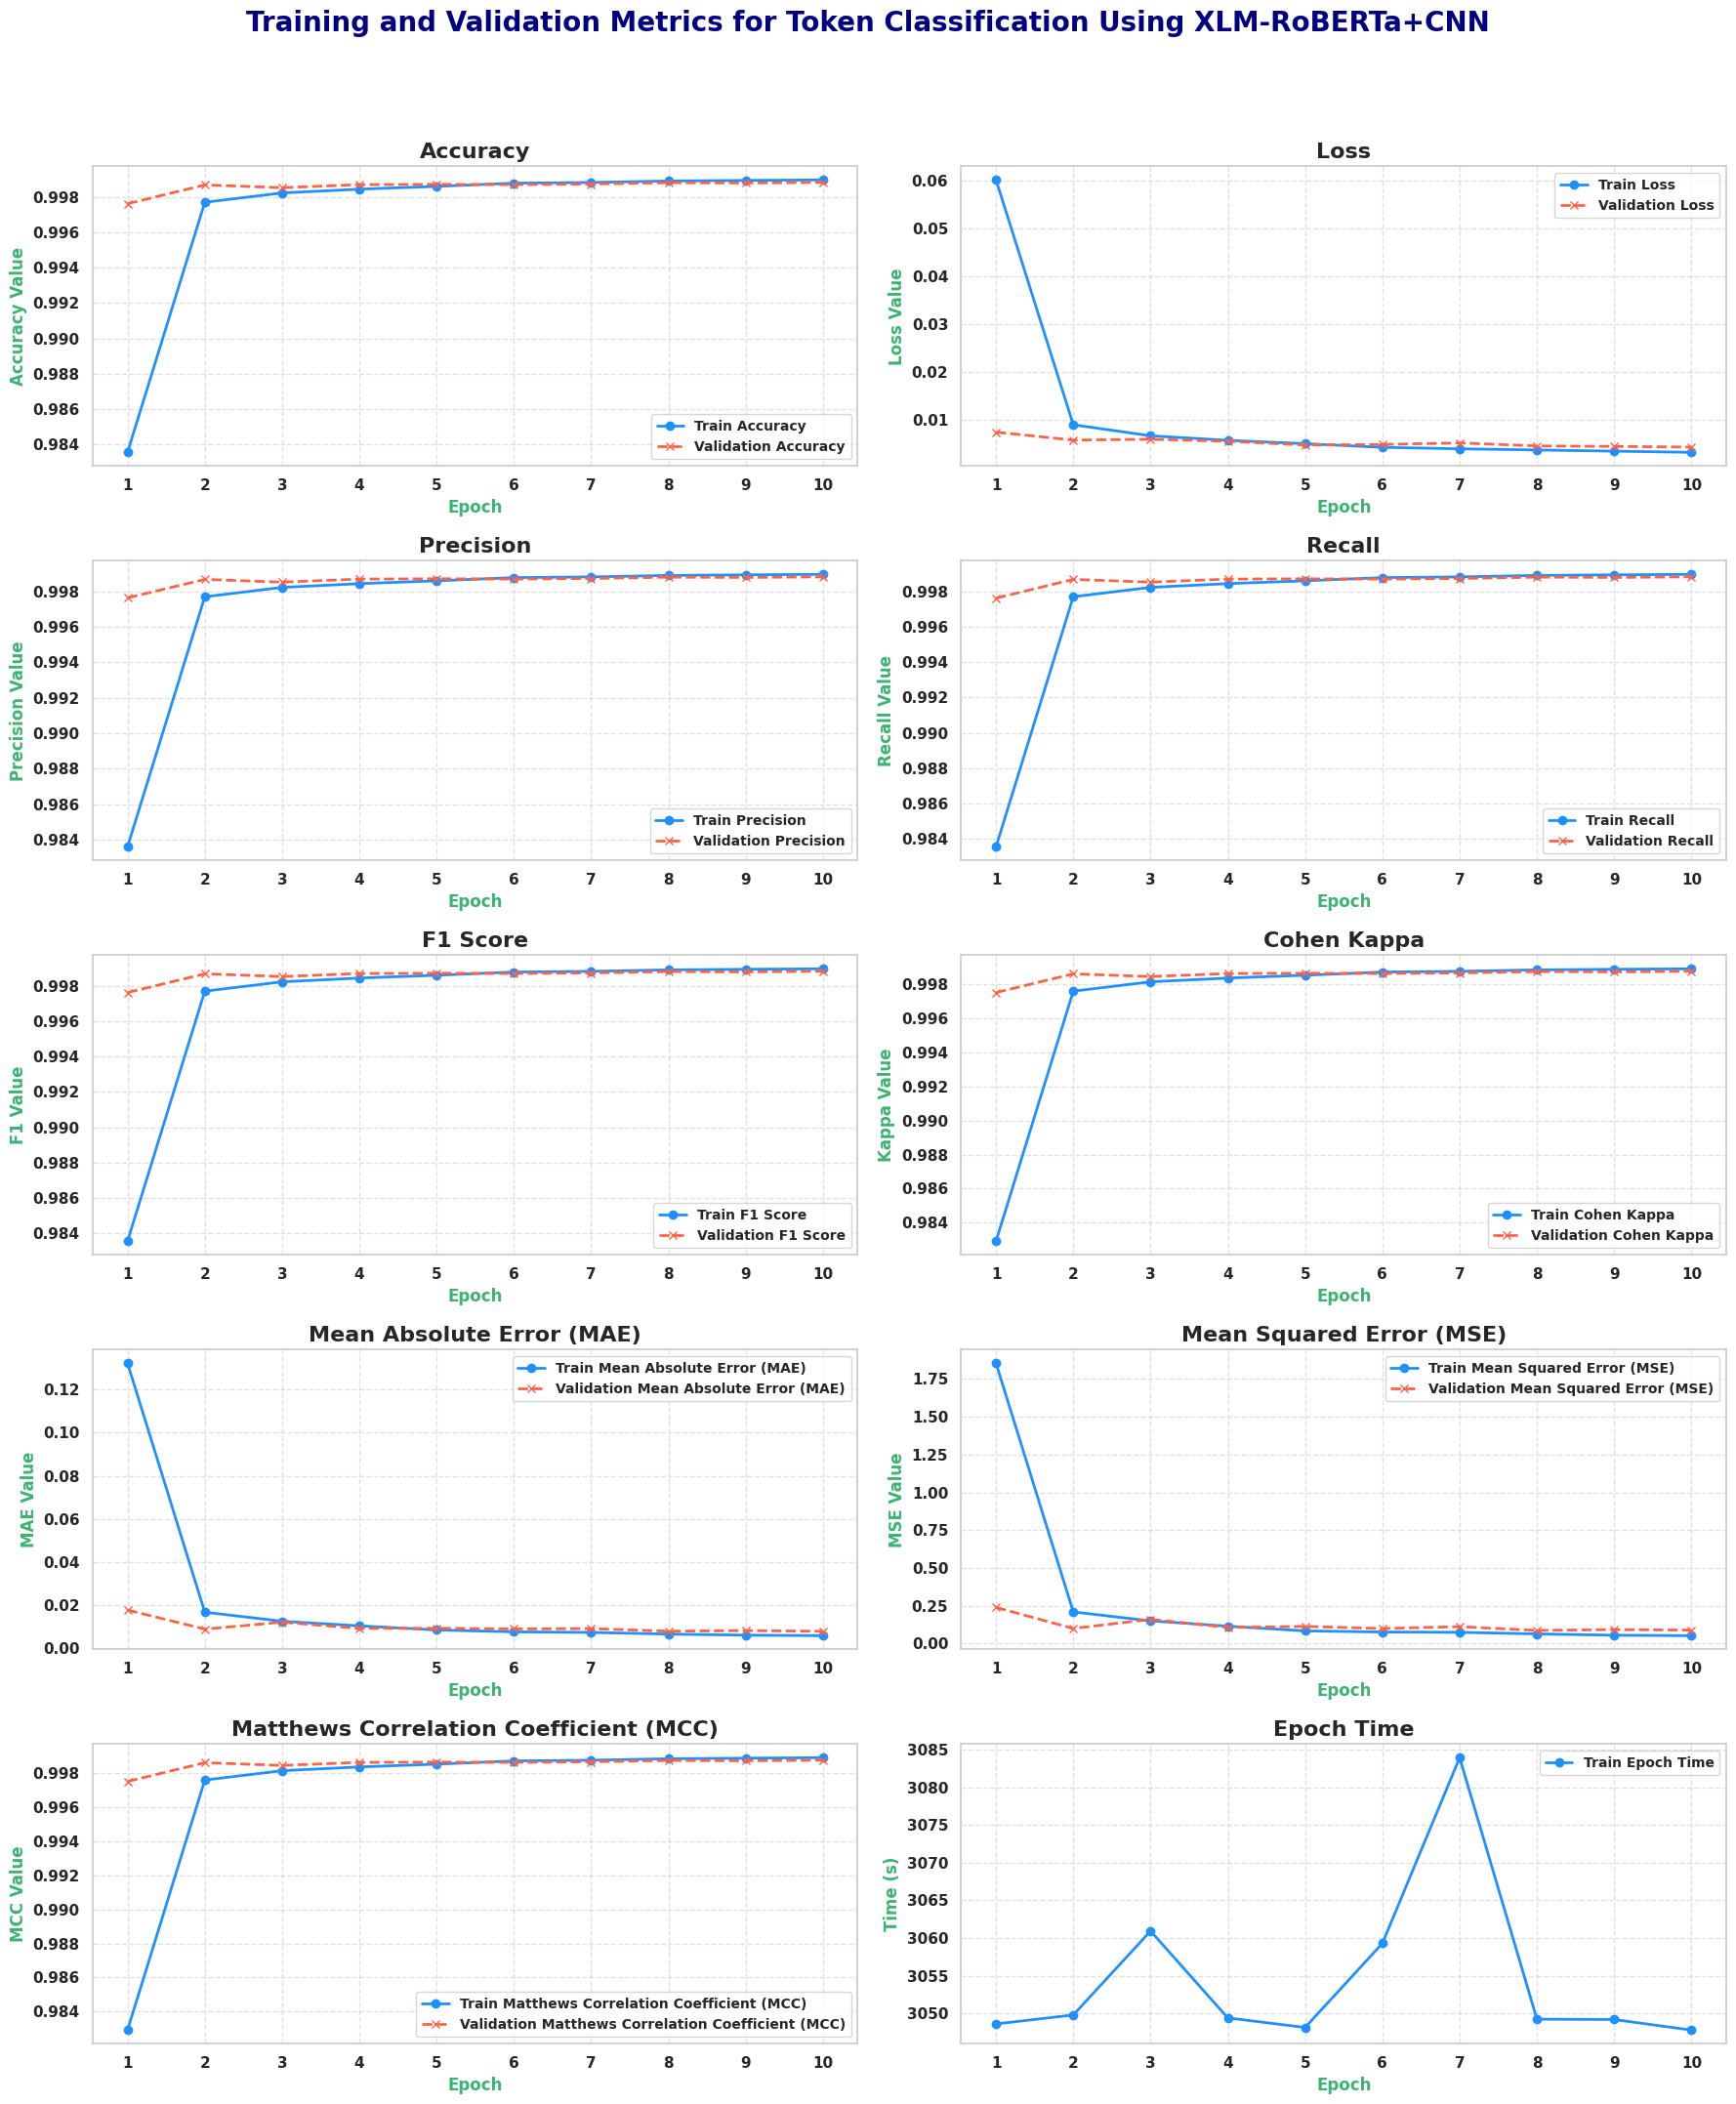

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def training_draw(history, title, save_path=None):
    # Set overall aesthetics
    sns.set(style="whitegrid")
    font = {'family': 'Courier New', 'weight': 'bold', 'size': 14}
    plt.rc('font', **font)

    # Create figure and axes
    f, axes = plt.subplots(5, 2, figsize=(18, 22))
    f.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)
    t = f.suptitle(title, fontsize=20, weight='bold', color='navy')

    # Create a color palette for the lines
    epoch_list = list(range(1, len(history.get('val_loss', [])) + 1))

    # Define helper function to plot
    def plot_metric(ax, train_metric, val_metric, label, ylabel, single_value=False):
        train_data = history.get(train_metric, [])
        val_data = history.get(val_metric, [])

        # Check if the data is available
        if len(train_data) > 0:
            # Plot training metric
            ax.plot(epoch_list, train_data, label=f'Train {label}', color='DodgerBlue', linestyle='-', marker='o', linewidth=2)

        if not single_value and len(val_data) > 0:
            # Plot validation metric only if it exists and is not None
            ax.plot(epoch_list, val_data, label=f'Validation {label}', color='Tomato', linestyle='--', marker='x', linewidth=2)

        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_xticks(np.arange(1, len(epoch_list) + 1, 1))
        ax.set_ylabel(ylabel, fontsize=12, color='MediumSeaGreen', weight='bold')
        ax.set_xlabel('Epoch', fontsize=12, color='MediumSeaGreen', weight='bold')
        ax.legend(loc="best", fontsize=10)
        ax.set_title(f'{label}', fontsize=16, weight='bold')

    # Plot Accuracy
    plot_metric(axes[0, 0], 'accuracy', 'val_accuracy', 'Accuracy', 'Accuracy Value')

    # Plot Loss
    plot_metric(axes[0, 1], 'loss', 'val_loss', 'Loss', 'Loss Value')

    # Plot Precision
    plot_metric(axes[1, 0], 'precision', 'val_precision', 'Precision', 'Precision Value')

    # Plot Recall
    plot_metric(axes[1, 1], 'recall', 'val_recall', 'Recall', 'Recall Value')

    # Plot F1 Score
    plot_metric(axes[2, 0], 'f1', 'val_f1', 'F1 Score', 'F1 Value')

    # Plot Cohen Kappa
    plot_metric(axes[2, 1], 'kappa', 'val_kappa', 'Cohen Kappa', 'Kappa Value')

    # Plot Mean Absolute Error
    plot_metric(axes[3, 0], 'mae', 'val_mae', 'Mean Absolute Error (MAE)', 'MAE Value')

    # Plot Mean Squared Error
    plot_metric(axes[3, 1], 'mse', 'val_mse', 'Mean Squared Error (MSE)', 'MSE Value')

    # Plot Matthews Correlation Coefficient
    plot_metric(axes[4, 0], 'mcc', 'val_mcc', 'Matthews Correlation Coefficient (MCC)', 'MCC Value')

    # Plot Epoch Time (Single value)
    if 'epoch_time' in history and len(history['epoch_time']) > 0:
        plot_metric(axes[4, 1], 'epoch_time', 'Nan', 'Epoch Time', 'Time (s)', single_value=True)
    else:
        axes[4, 1].set_visible(False)

    # Final adjustments and show plot
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save plot to file if a path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')  # Save the plot as a file
    plt.show()

training_draw(history, 'Training and Validation Metrics '+title, save_path=title_figure+"_metrics_plot.png")

In [39]:
from torch.utils.data import DataLoader
test_dataloader = DataLoader(
    tokenized_test_datasets, batch_size=32, collate_fn=data_collator
)

In [40]:
device = config.device

In [41]:
model = ClassifierModel()
model.bert.resize_token_embeddings(len(tokenizer))

Embedding(250041, 768, padding_idx=1)

In [42]:
model_path = f""+model_name+"_model_v1.bin"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [43]:
model.to(device)

ClassifierModel(
  (bert): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250041, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
       

In [44]:
model.eval()
prediction = []
for batch in test_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(input_ids = batch['input_ids'], attention_mask = batch['attention_mask'])
        logits = outputs
        pred = torch.argmax(logits, dim=-1)
        prediction.extend(pred.cpu().numpy().tolist())

In [45]:
y_true = test_df.LABEL.values
y_pred = prediction

In [46]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    classification_report,
    precision_score,
    recall_score,
    mean_squared_error,
    mean_absolute_error,
    cohen_kappa_score
)
#ypred_cnn_ctw = cnn_ctw_model.predict(x_test_cnn_ctw)

accuray = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(model_name)
print("Accuracy:", accuray)
print("precision:", precision)
print("recall:", recall)
print("F1 Score:", f1)
print("MSE:", mse)
print("MAE:", mae)
print("Kappa:", kappa)

XLM-RoBERTa+CNN
Accuracy: 0.9989145299145299
precision: 0.9989184045068382
recall: 0.9989145299145299
F1 Score: 0.9989141511343725
MSE: 0.06735897435897435
MAE: 0.006726495726495726
Kappa: 0.9988711111111112


In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
#labels = ['HAPPY', 'SAD', 'ANGRY', 'FEAR', 'SURPRIZE', 'NEUTRAL']
labels = ['BNG_TEXT', 'ENG_TEXT', 'ORDINAL', 'FLOAT', 'FRACTIONAL', 'DATE',
       'TELEPHONE', 'GAME', 'PERCENTAGE', 'EQUATION', 'HOMO_TEXT', 'RANGE',
       'NON_HOMO_TEXT', 'CARDINAL', 'ROMAN_NUM', 'MONEY', 'ENG_NUM', 'YEAR',
       'TIME', 'ARABIC_TEXT', 'OTHERS_TEXT', 'PUNCTUATION', 'UNKNOWN_TOKEN',
       'SPECIAL SIGN', 'ABBREVIATION', 'EMOZI']
from sklearn import metrics

y_pred_label = [labels[int(x)] for x in y_pred]
y_true_label = [labels[int(x)] for x in y_true]
print(metrics.classification_report(y_true_label, y_pred_label))

               precision    recall  f1-score   support

 ABBREVIATION       1.00      1.00      1.00      4500
  ARABIC_TEXT       1.00      1.00      1.00      4500
     BNG_TEXT       1.00      1.00      1.00      4500
     CARDINAL       0.99      0.99      0.99      4500
         DATE       1.00      1.00      1.00      4500
        EMOZI       1.00      1.00      1.00      4500
      ENG_NUM       1.00      1.00      1.00      4500
     ENG_TEXT       1.00      1.00      1.00      4500
     EQUATION       1.00      1.00      1.00      4500
        FLOAT       1.00      1.00      1.00      4500
   FRACTIONAL       1.00      1.00      1.00      4500
         GAME       1.00      1.00      1.00      4500
    HOMO_TEXT       1.00      1.00      1.00      4500
        MONEY       1.00      1.00      1.00      4500
NON_HOMO_TEXT       1.00      1.00      1.00      4500
      ORDINAL       1.00      0.99      0.99      4500
  OTHERS_TEXT       1.00      1.00      1.00      4500
   PERCEN

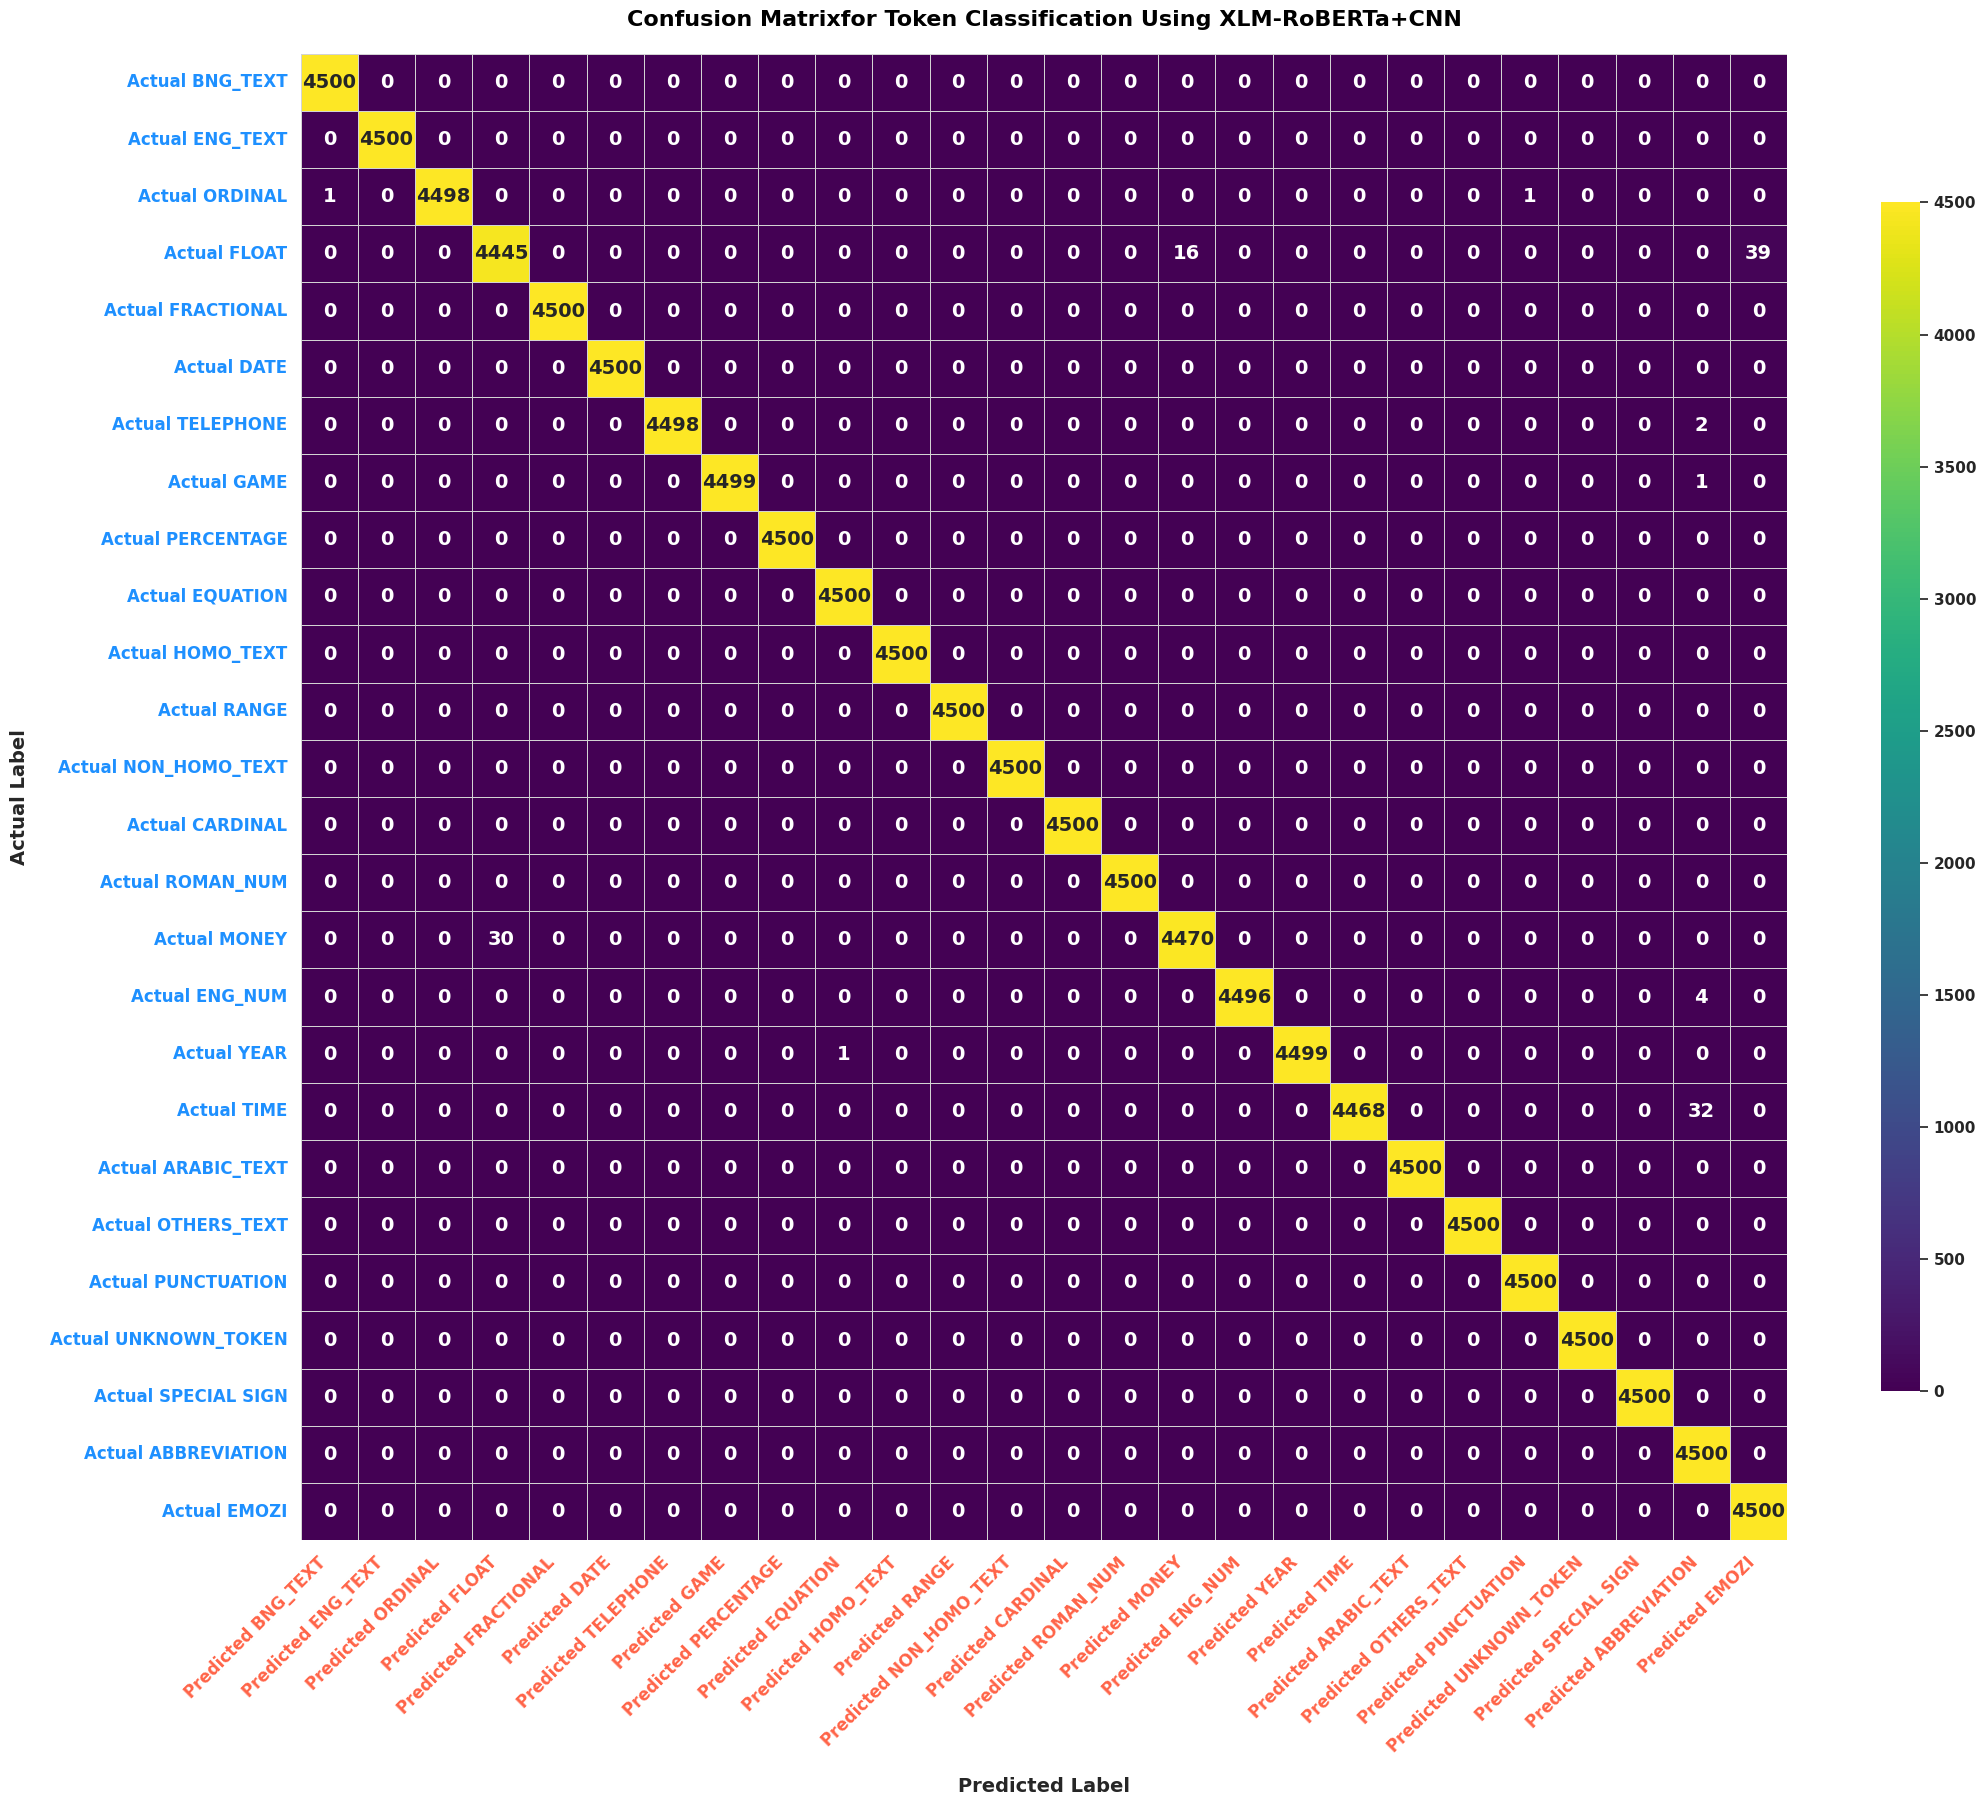

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Set aesthetic parameters for the plot
sns.set(style="white", palette="pastel")  # Lighter and more subtle palette
font = {'family': 'courier new', 'weight': 'bold', 'size': 12}
plt.rc('font', **font)

# Function to plot a light and beautiful confusion matrix
def plot_confusion_matrix(y_true, y_pred, labels, save_path=None):
    columns = [f'Predicted {label}' for label in labels]
    index = [f'Actual {label}' for label in labels]
    
    # Create confusion matrix as a DataFrame
    cm = confusion_matrix(y_true, y_pred)
    table = pd.DataFrame(cm, columns=columns, index=index)
    
    # Set up the figure and axis with lighter, airy sizing
    plt.figure(figsize=(22, 18))
    
    # Create heatmap with a soft, pastel color palette
    sns.heatmap(table, annot=True, fmt='d', cmap='viridis',  # 'Blues' for a soft and clean look
                cbar_kws={'shrink': 0.8, 'aspect': 30},  # Colorbar adjustments
                linewidths=0.5, linecolor='lightgrey',  # Soft gridlines
                annot_kws={"size": 14, "weight": "bold"},  # Softer annotations
                square=True)  # Keep the cells square for balance

    # Add lighter, elegant titles and labels
    plt.title('Confusion Matrix'+title, fontsize=16, weight='bold', pad=20, color='black')
    plt.ylabel('Actual Label', fontsize=14, weight='bold', labelpad=15)
    plt.xlabel('Predicted Label', fontsize=14, weight='bold', labelpad=15)

    # Customizing x and y tick labels for clarity with a soft, clean color
    plt.xticks(rotation=45, ha='right', fontsize=12, weight='bold', color='Tomato')
    plt.yticks(rotation=0, fontsize=12, weight='bold', color='DodgerBlue')
    
    # Tighter layout for a neat appearance
    plt.tight_layout()
        # Save plot to file if a path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')  # Save the plot as a file
    plt.show()


plot_confusion_matrix(y_true_label, y_pred_label, labels, save_path=title_figure+"_confusion_metrics_plot.png")


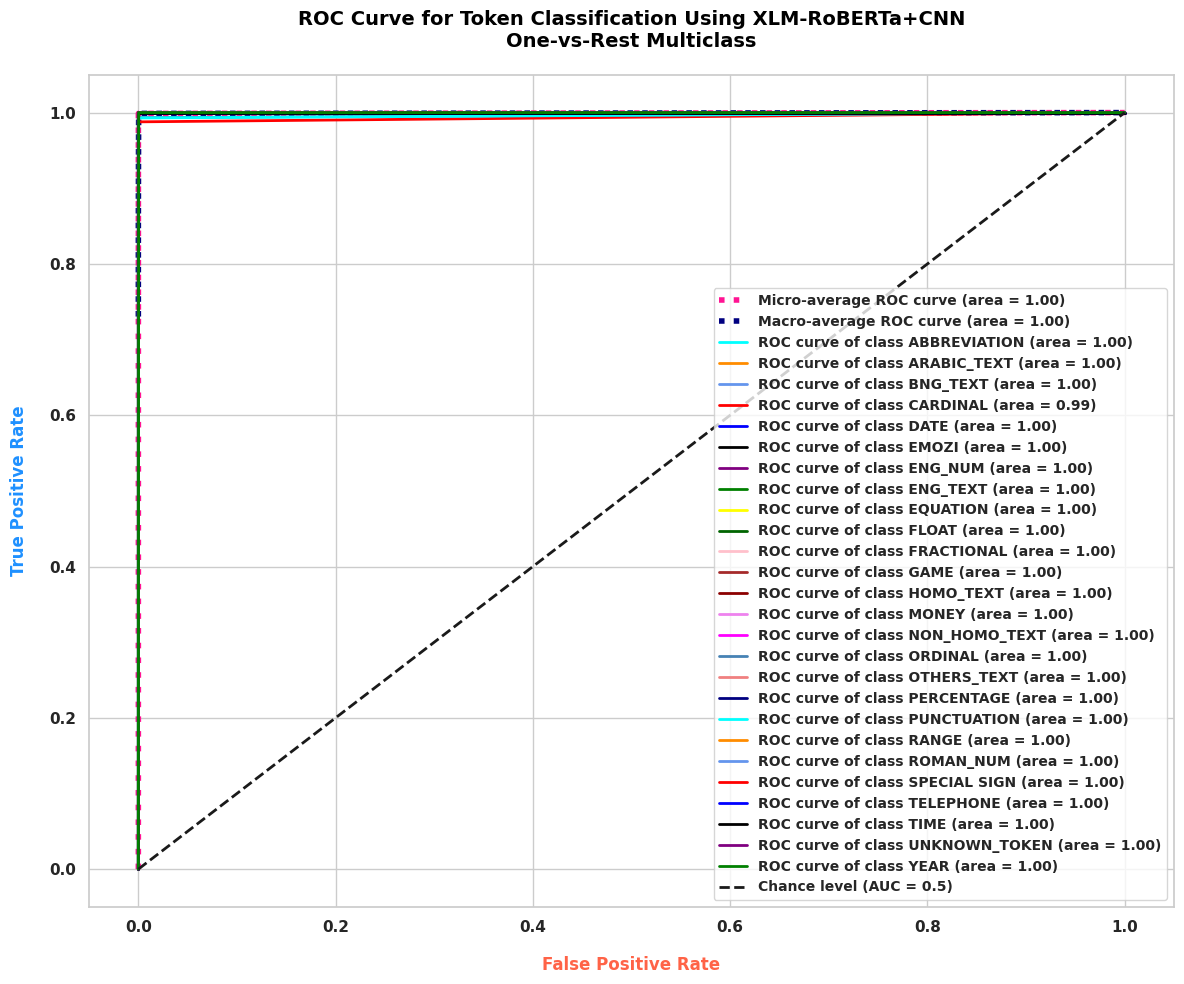

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Set aesthetic parameters for the plot
sns.set(style="whitegrid", palette="pastel")
font = {'family': 'Courier New', 'weight': 'bold', 'size': 12}
plt.rc('font', **font)

# Function to calculate the ROC curve data for multiclass classification
def classification_report_df(y_true, y_pred):
    classes = np.unique(y_true)
    true = label_binarize(y_true, classes=classes)
    pred = label_binarize(y_pred, classes=classes)

    fpr, tpr, roc_auc = {}, {}, {}
    for i, c in enumerate(classes):
        fpr[c], tpr[c], _ = roc_curve(true[:, i], pred[:, i])
        roc_auc[c] = auc(fpr[c], tpr[c])

    # Micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(true.ravel(), pred.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    return fpr, tpr, roc_auc, classes

# Function to plot the ROC curve for multiclass classification
def plot_multiclass_roc(y_true, y_pred, plot_title, save_path=None):
    fpr, tpr, roc_auc, classes = classification_report_df(y_true, y_pred)
    
    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[c] for c in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in classes:
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= len(classes)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Create the plot
    plt.figure(figsize=(12, 10))
    
    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC curve (area = {roc_auc["micro"]:0.2f})',
             color='deeppink', linestyle=':', linewidth=4)
    
    # Plot macro-average ROC curve
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average ROC curve (area = {roc_auc["macro"]:0.2f})',
             color='navy', linestyle=':', linewidth=4)
    
    # Plot ROC curve for each class with different colors
    colors = cycle(["aqua", "darkorange", "cornflowerblue", "red", "blue", "black", "purple", "green", "yellow",
                    "darkgreen", "pink", "brown", "darkred", "violet", "magenta", "steelblue", "lightcoral", "navy"])
    for c, color in zip(classes, colors):
        plt.plot(fpr[c], tpr[c], color=color, lw=2,
                 label=f'ROC curve of class {c} (area = {roc_auc[c]:0.2f})')
    
    # Plot the random guess line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance level (AUC = 0.5)")
    
    # Set the plot labels and title
    plt.xlabel("False Positive Rate", fontsize=12, color='Tomato', weight='bold', labelpad=15)
    plt.ylabel("True Positive Rate", fontsize=12, color='DodgerBlue', weight='bold', labelpad=15)
    plt.title(plot_title, fontsize=14, color='black', weight='bold', pad=20)
    
    # Add a legend
    plt.legend(loc="lower right", fontsize=10)
    
    # Adjust layout for better appearance
    plt.tight_layout()
    
    # Save the plot to file if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Display the plot
    plt.show()

# Example usage (replace with actual labels and data)
plot_title = "ROC Curve "+title+"\nOne-vs-Rest Multiclass"
plot_multiclass_roc(y_true_label, y_pred_label, plot_title, save_path=title_figure+"_roc_plot.png")

In [50]:
# Define TCN Module
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2):
        super(TCNBlock, self).__init__()
        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=(kernel_size - 1) * dilation // 2,  # Causal padding
        )
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.norm(x)
        x = self.dropout(x)
        return x

# Define mBERT + TCN Classifier
class ClassifierModel(nn.Module):
    def __init__(self):
        super(ClassifierModel, self).__init__()
        self.bert = AutoModel.from_pretrained(config.path)
        self.tcn = nn.Sequential(
            TCNBlock(in_channels=768, out_channels=256, kernel_size=3, dilation=1),
            TCNBlock(in_channels=256, out_channels=128, kernel_size=3, dilation=2),
        )
        self.drop = nn.Dropout(p=0.45)
        self.fc = nn.Linear(128, config.num_classes)

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_output.last_hidden_state.transpose(1, 2)  # Shape: [batch_size, hidden_dim, seq_len]
        x = self.tcn(x)  # Apply TCN
        x = x.max(dim=2)[0]  # Global max-pooling
        x = self.drop(x)
        return self.fc(x)